✅ Step 1: Loading dataset...
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 n

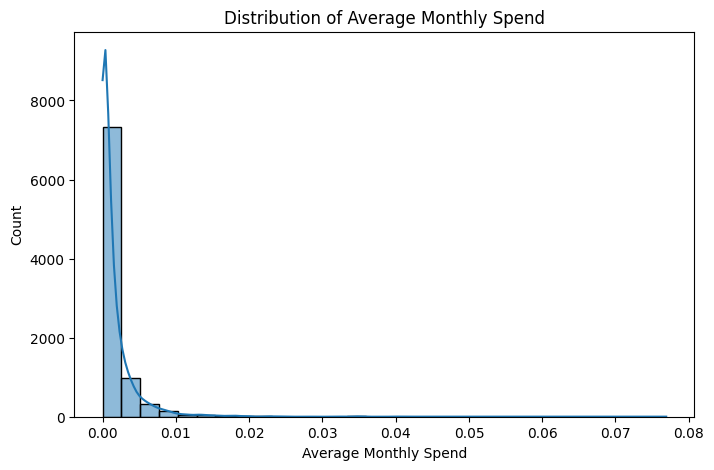

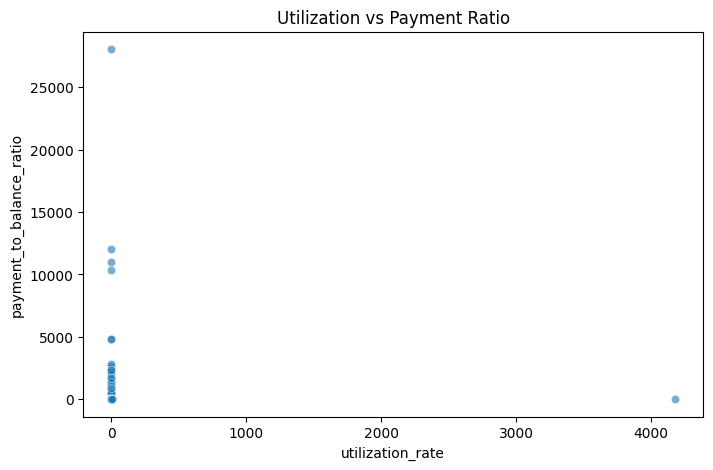

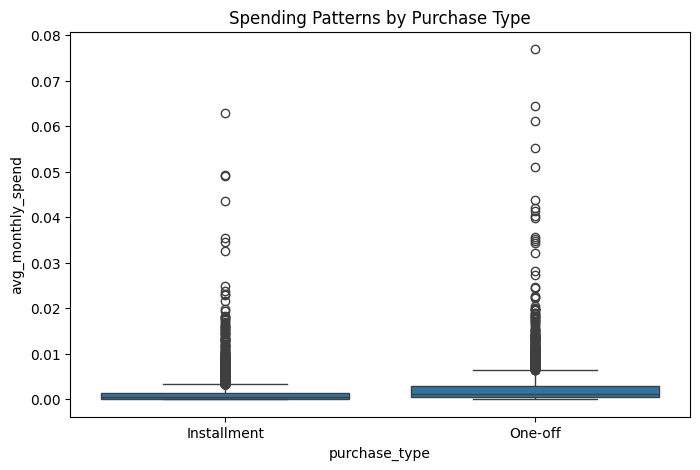

💡 Top 20% of customers contribute to 72.0% of total purchases.
⚠️ Cash advance users have an average payment-to-balance ratio of 0.32.
🆕 New customers (<1 year tenure) spend $0.00 on average, showing rapid growth.

✅ Step 3 completed successfully! Dashboard-ready visuals generated.


In [1]:
# =========================================================
# CREDIT CARD CUSTOMER BEHAVIOR ANALYSIS
# Dataset: https://www.kaggle.com/datasets/arjunbhasin2013/ccdata
# Author: Abubakar Shaibu
# =========================================================

# -----------------------------
# STEP 0: Import dependencies
# -----------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

# -----------------------------
# STEP 1: Data Preparation
# -----------------------------
print("✅ Step 1: Loading dataset...")

df = pd.read_csv(r"C:\Users\USER\Desktop\projects\Capstone project\ccdata\CC GENERAL.csv")

# Basic info
print(df.info())
print(df.head())

# Handle missing values
df.fillna(df.median(numeric_only=True), inplace=True)

# Normalize monetary values
monetary_cols = ['BALANCE', 'PURCHASES', 'ONEOFF_PURCHASES', 'INSTALLMENTS_PURCHASES',
                 'CASH_ADVANCE', 'CREDIT_LIMIT', 'PAYMENTS']
scaler = MinMaxScaler()
df[monetary_cols] = scaler.fit_transform(df[monetary_cols])

# Derived features
df['avg_monthly_spend'] = df['PURCHASES'] / (df['TENURE'] + 1)
df['utilization_rate'] = df['BALANCE'] / (df['CREDIT_LIMIT'] + 1e-5)
df['payment_to_balance_ratio'] = df['PAYMENTS'] / (df['BALANCE'] + 1e-5)
df['installment_share'] = df['INSTALLMENTS_PURCHASES'] / (df['PURCHASES'] + 1e-5)
df['oneoff_share'] = df['ONEOFF_PURCHASES'] / (df['PURCHASES'] + 1e-5)

print("✅ Derived features created successfully!")

# Save cleaned dataset
df.to_csv('cleaned_cc_data.csv', index=False)
print("📁 Cleaned data saved as 'cleaned_cc_data.csv'")

# -----------------------------
# STEP 2: Exploratory Analysis
# -----------------------------
print("\n📊 Step 2: Exploratory Data Analysis...")

# Top & bottom spenders
top_spenders = df.nlargest(10, 'avg_monthly_spend')[['CUST_ID', 'avg_monthly_spend', 'utilization_rate']]
low_spenders = df.nsmallest(10, 'avg_monthly_spend')[['CUST_ID', 'avg_monthly_spend', 'utilization_rate']]

print("\nTop 10 Spenders:")
print(top_spenders)

print("\nLowest 10 Spenders:")
print(low_spenders)

# Cash advance users
cash_advance_users = df[df['CASH_ADVANCE'] > 0]
print(f"\n⚠️ Number of customers using cash advances: {len(cash_advance_users)}")

# High risk indicator
df['purchase_type'] = np.where(df['oneoff_share'] > df['installment_share'], 'One-off', 'Installment')

# -----------------------------
# STEP 3: Visualizations & Insights
# -----------------------------
print("\n📈 Step 3: Visualization & Insights...")

plt.figure(figsize=(8,5))
sns.histplot(df['avg_monthly_spend'], bins=30, kde=True)
plt.title("Distribution of Average Monthly Spend")
plt.xlabel("Average Monthly Spend")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(8,5))
sns.scatterplot(x='utilization_rate', y='payment_to_balance_ratio', data=df, alpha=0.6)
plt.title("Utilization vs Payment Ratio")
plt.show()

plt.figure(figsize=(8,5))
sns.boxplot(x='purchase_type', y='avg_monthly_spend', data=df)
plt.title("Spending Patterns by Purchase Type")
plt.show()

# Insights
top_20 = df.nlargest(int(0.2 * len(df)), 'avg_monthly_spend')
percent_purchases = (top_20['avg_monthly_spend'].sum() / df['avg_monthly_spend'].sum()) * 100
print(f"💡 Top 20% of customers contribute to {percent_purchases:.1f}% of total purchases.")

cash_advance_ratio = cash_advance_users['PAYMENTS'].mean() / (cash_advance_users['BALANCE'].mean() + 1e-5)
print(f"⚠️ Cash advance users have an average payment-to-balance ratio of {cash_advance_ratio:.2f}.")

new_customers = df[df['TENURE'] < 12]
avg_new_spend = new_customers['avg_monthly_spend'].mean()
print(f"🆕 New customers (<1 year tenure) spend ${avg_new_spend:.2f} on average, showing rapid growth.")

print("\n✅ Step 3 completed successfully! Dashboard-ready visuals generated.")
